In [ ]:
#install.packages("Matrix")
#install.packages("glmnet")

In [77]:
library(ggplot2)
library(lattice)
library(caret)
library(tictoc)

In [11]:
dataNN <- read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
testNN <- read.csv("test_target_encoding_NN.csv",stringsAsFactors = T)

In [12]:
options(repr.matrix.max.cols=100)
dataNN[1:3,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,land_surface_condition_n,land_surface_condition_o,land_surface_condition_t,foundation_type_h,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_n,roof_type_q,roof_type_x,ground_floor_type_f,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_j,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_j,position_o,position_s,position_t,plan_configuration_a,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_a,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,damage_grade_X1,damage_grade_X2,damage_grade_X3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,-0.7582801,-1.622914,-0.7117704,-1.755598,-0.6703393,-1.595431,-1.5527243,0.1865827,-0.6866562,-1.7901472,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,1.9332117,-2.031207,2.0648268,-3.158564,1.9075085,-2.585391,-0.1777897,-1.0884839,1.1340897,0.8168333,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,1.9332117,-2.031207,2.0853139,-3.404859,1.9075085,-2.585391,-0.1777897,-0.8334706,0.9064964,0.2954372,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1


In [13]:
dataNN[1:3,c(34,37,42,45,50,54,58,68)]

,land_surface_condition_o,foundation_type_i,roof_type_q,ground_floor_type_m,other_floor_type_q,position_o,plan_configuration_c,legal_ownership_status_r
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0
3,1,0,1,0,1,0,0,0


In [14]:
dataNN <- dataNN[,-c(34,37,42,45,50,54,58,68)]

In [15]:
dataNN[1:2,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,land_surface_condition_n,land_surface_condition_t,foundation_type_h,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_n,roof_type_x,ground_floor_type_f,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_j,other_floor_type_s,other_floor_type_x,position_j,position_s,position_t,plan_configuration_a,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_a,legal_ownership_status_v,legal_ownership_status_w
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,-0.7582801,-1.622914,-0.7117704,-1.755598,-0.6703393,-1.595431,-1.5527243,0.1865827,-0.6866562,-1.7901472,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
2,1.9332117,-2.031207,2.0648268,-3.158564,1.9075085,-2.585391,-0.1777897,-1.0884839,1.1340897,0.8168333,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0


In [16]:
nzv <- nearZeroVar(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
dataNN <- dataNN[, -nzv]

### Linear Regression of an Indicator Matrix

Voir : chapitre 4.2 The elements of statistical learning

In [17]:
dataNN[1:2,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,count_families,has_secondary_use_agriculture,land_surface_condition_n,land_surface_condition_t,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_n,roof_type_x,ground_floor_type_f,ground_floor_type_v,ground_floor_type_x,other_floor_type_j,other_floor_type_x,position_j,position_s,position_t,damage_grade_X1,damage_grade_X2,damage_grade_X3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,-0.7582801,-1.622914,-0.7117704,-1.755598,-0.6703393,-1.595431,-1.5527243,0.1865827,-0.6866562,-1.7901472,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0
2,1.9332117,-2.031207,2.0648268,-3.158564,1.9075085,-2.585391,-0.1777897,-1.0884839,1.1340897,0.8168333,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1


In [70]:
k = 5
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN))
max <- ceiling(nrow(dataNN)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

X <- as.matrix(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){
        cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1
    }
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.718978


In [82]:
which(grepl('damage_grade',colnames(dataNN)))

[1] 34 35 36

In [83]:
set.seed(2)

n<-ncol(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))
correlation<-abs(cor(dataNN[,-targets,drop=F],dataNN[,targets,drop=F]))
selected<-c()
candidates<-1:(n-length(targets))

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(dataNN[,selected,drop=F],dataNN[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    rankingNN <- selected

In [84]:
rankingNN
colnames(dataNN)[rankingNN]

[1]  5 27 26 25 21 23 12 14  4  3  6  8 29  1  2 22 24  7  9 15 11 32 28 18 17
[26] 19 20 33 16 13 30 10 31

[1] "geo_level_3_mean_damage"               
 [2] "ground_floor_type_v"                   
 [3] "ground_floor_type_f"                   
 [4] "roof_type_x"                           
 [5] "foundation_type_r"                     
 [6] "foundation_type_w"                     
 [7] "has_superstructure_mud_mortar_stone"   
 [8] "has_superstructure_cement_mortar_brick"
 [9] "geo_level_2_sd_damage"                 
[10] "geo_level_2_mean_damage"               
[11] "geo_level_3_sd_damage"                 
[12] "age"                                   
[13] "other_floor_type_j"                    
[14] "geo_level_1_mean_damage"               
[15] "geo_level_1_sd_damage"                 
[16] "foundation_type_u"                     
[17] "roof_type_n"                           
[18] "count_floors_pre_eq"                   
[19] "area_percentage"                       
[20] "has_superstructure_timber"             
[21] "has_superstructure_adobe_mud"          
[22] "position_s"                            
[23] "ground_floor_type_x"                   
[24] "has_secondary_use_agriculture"         
[25] "count_families"                        
[26] "land_surface_condition_n"              
[27] "land_surface_condition_t"              
[28] "position_t"                            
[29] "has_superstructure_bamboo"             
[30] "has_superstructure_mud_mortar_brick"   
[31] "other_floor_type_x"                    
[32] "height_percentage"                     
[33] "position_j"

In [85]:
length(rankingNN)

[1] 33

In [86]:
dim(dataNN)

[1] 259211     36

In [112]:
set.seed(3)

k = 5
accuracy_matrix <- matrix(0, nrow = (length(seq(2,length(rankingNN),1))), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = (length(seq(2,length(rankingNN),1))-1), style = 3)

X <- as.matrix(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])


for (l in seq(2,length(rankingNN),1)){
    X <- as.matrix(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y <- as.matrix(dataNN[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X <- X[,rankingNN[1:l]]
    
    Shuffle_idx <- sample(1:nrow(dataNN))
    max <- ceiling(nrow(dataNN)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    tic()
    for (i in 1:k){
        X.test <- X[splits[[i]],]
        y.test <-  y[splits[[i]],]
        X.train <- X[-splits[[i]],]
        y.train <-  y[-splits[[i]],]
    
        X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

        beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
        pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

        cm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:nrow(X.test)){
            cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1
        }
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[l-1,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
    setTxtProgressBar(pb1, l-1)
    print(mean(accuracy_matrix[l-1,]))
    toc()
}

  |                                                                      |   0%[1] 0.7110314
  |==================                                                    |  25%[1] 0.710202
  |===================================                                   |  50%[1] 0.7107613
  |====================================================                  |  75%[1] 0.7142526
  |======================================================================| 100%[1] 0.7105654
  |                                                                      |   0%[1] 0.7113625
0.6 sec elapsed
  |                                                                      |   0%[1] 0.709604
  |==================                                                    |  25%[1] 0.7099898
  |===================================                                   |  50%[1] 0.711938
  |====================================================                  |  75%[1] 0.7140598
  |======================================================

  |==================                                                    |  25%[1] 0.7192485
  |===================================                                   |  50%[1] 0.720348
  |====================================================                  |  75%[1] 0.7169724
  |======================================================================| 100%[1] 0.7206929
  |=================================                                     |  47%[1] 0.7189279
1.048 sec elapsed
  |                                                                      |   0%[1] 0.7200586
  |==================                                                    |  25%[1] 0.7190556
  |===================================                                   |  50%[1] 0.7207145
  |====================================================                  |  75%[1] 0.716413
  |======================================================================| 100%[1] 0.717047
  |===================================                 

  |===================================                                   |  50%[1] 0.7202901
  |====================================================                  |  75%[1] 0.7200008
  |======================================================================| 100%[1] 0.7197863
  |=================================================================     |  93%[1] 0.7189163
1.71 sec elapsed
  |                                                                      |   0%[1] 0.7201744
  |==================                                                    |  25%[1] 0.7184962
  |===================================                                   |  50%[1] 0.7190556
  |====================================================                  |  75%[1] 0.7156415
  |======================================================================| 100%[1] 0.7209244
  |====================================================================  |  97%[1] 0.7188584
1.72 sec elapsed
  |                                 

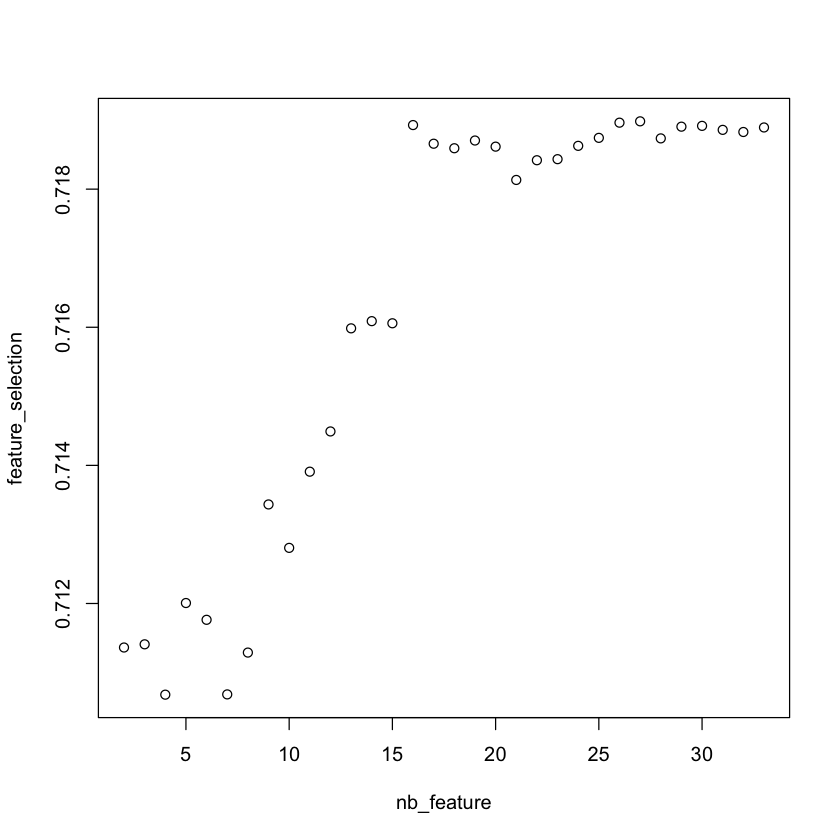

In [115]:
feature_selection <- accuracy_matrix %*% c(1/5,1/5,1/5,1/5,1/5)
nb_feature <- seq(2,length(rankingNN),1)
plot(nb_feature,feature_selection)

On vas tester d'enlever tous les feature apres 16

In [116]:
set.seed(20)

k = 5
accuracy_matrix <- matrix(0, nrow = 15, ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = 15, style = 3)

X <- as.matrix(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])


for (l in 2:16){
    X <- X[,rankingNN[1:l]]
    
    Shuffle_idx <- sample(1:nrow(dataNN))
    max <- ceiling(nrow(dataNN)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    tic()
    for (i in 1:k){
        X.test <- X[splits[[i]],]
        y.test <-  y[splits[[i]],]
        X.train <- X[-splits[[i]],]
        y.train <-  y[-splits[[i]],]
    
        X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

        beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
        pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

        cm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:nrow(X.test)){
            cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1
        }
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[l-1,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
    setTxtProgressBar(pb1, l-1)
    print(mean(accuracy_matrix[l-1,]))
    toc()
}

  |                                                                      |   0%[1] 0.7097004
  |==================                                                    |  25%[1] 0.7117065
  |===================================                                   |  50%[1] 0.7131339
  |====================================================                  |  75%[1] 0.712208
  |======================================================================| 100%[1] 0.7096588
  |                                                                      |   0%[1] 0.7112815
0.609 sec elapsed
  |                                                                      |   0%[1] 0.7091218
  |==================                                                    |  25%[1] 0.7119958
  |===================================                                   |  50%[1] 0.7128831
  |====================================================                  |  75%[1] 0.7124395
  |==================================================

  |==================                                                    |  25%[1] 0.7206759
  |===================================                                   |  50%[1] 0.7153907
  |====================================================                  |  75%[1] 0.7188049
  |======================================================================| 100%[1] 0.7168734
  |======================================================================| 100%[1] 0.7189008
1.044 sec elapsed


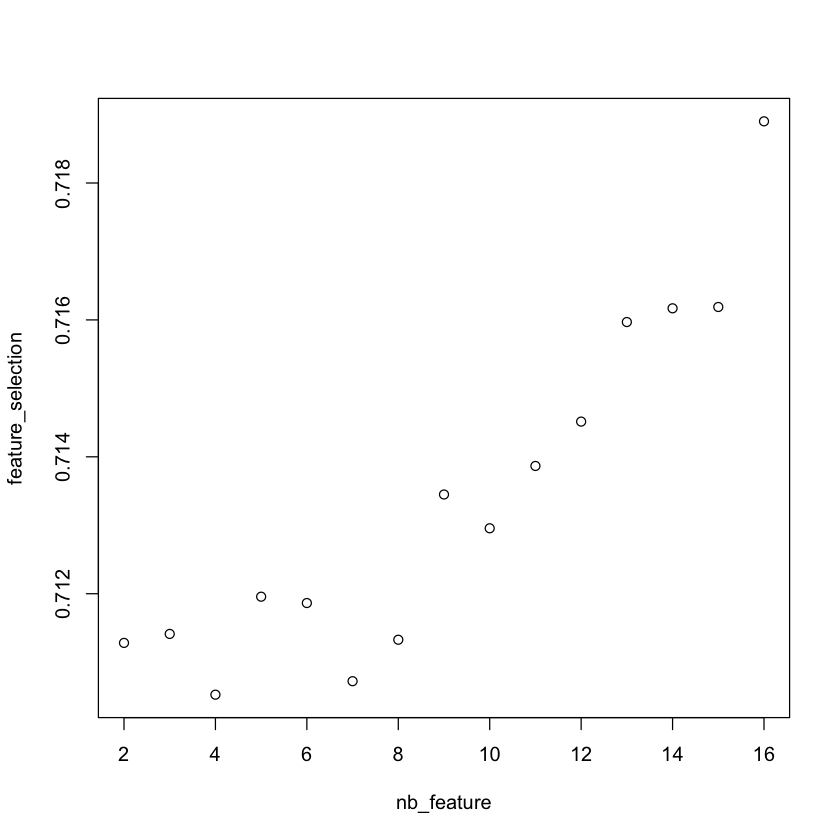

In [117]:
feature_selection <- accuracy_matrix %*% c(1/5,1/5,1/5,1/5,1/5)
nb_feature <- 2:16
plot(nb_feature,feature_selection)

teston d'enlever les feature 4 

In [121]:
set.seed(330)

k = 5
accuracy_vec <- 1:k



X <- as.matrix(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN[c(1,2,3,5,6,7,8,9,10,11,12,13,14,15,16)]]
Shuffle_idx <- sample(1:nrow(dataNN))
max <- ceiling(nrow(dataNN)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
tic()
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.7166445
  |==================                                                    |  25%[1] 0.7157765
  |===================================                                   |  50%[1] 0.7158729
  |====================================================                  |  75%[1] 0.7189206
  |======================================================================| 100%[1] 0.7237794
[1] 0.7181988
1.216 sec elapsed


In [120]:
set.seed(44)

k = 5
accuracy_vec <- 1:k



X <- as.matrix(dataNN[,setdiff(colnames(dataNN),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN[c(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16)]]
Shuffle_idx <- sample(1:nrow(dataNN))
max <- ceiling(nrow(dataNN)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
tic()
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.7169724
  |==================                                                    |  25%[1] 0.7170303
  |===================================                                   |  50%[1] 0.7200393
  |====================================================                  |  75%[1] 0.7191521
  |======================================================================| 100%[1] 0.7213681
[1] 0.7189124
1.059 sec elapsed


On n'obtient pas d'améloration en elevant le feature 4 